# GameTheory-06-EvolutionTrust

**Navigation** : [<< 5-ZeroSum-Minimax](GameTheory-05-ZeroSum-Minimax.ipynb) | [Index](README.md) | [7-ExtensiveForm >>](GameTheory-07-ExtensiveForm.ipynb)

## Evolution de la Confiance et Dilemme du Prisonnier Itere

Ce notebook explore le **Dilemme du Prisonnier Itere** (IPD) et l'evolution de la cooperation, inspire par le travail d'Axelrod et la simulation interactive ["The Evolution of Trust"](https://ncase.me/trust/) de Nicky Case.

### Objectifs d'apprentissage

1. Comprendre le Dilemme du Prisonnier Itere
2. Implementer les stratégies classiques (Tit-for-Tat, Hawks, Doves...)
3. Reproduire le tournoi d'Axelrod (1984)
4. Simuler l'evolution des populations (replicator dynamics)
5. Identifier les conditions pour l'emergence de la cooperation

### Prerequis

- Notebooks 1-5 : Fondations, equilibres de Nash, jeux a somme nulle
- Notion de stratégie dominante et de dilemme du prisonnier
- Bases de dynamique des systèmes (optionnel)

### Duree estimee : 65 minutes

### References
- Axelrod, R. (1984). *The Evolution of Cooperation*
- Nicky Case - [The Evolution of Trust](https://ncase.me/trust/)

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from typing import List, Tuple, Dict, Callable
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
print("Imports OK : numpy, matplotlib, random")


Imports OK : numpy, matplotlib, random


## 1. Le Dilemme du Prisonnier Itere (IPD)

### Du jeu unique au jeu repete

Dans le Dilemme du Prisonnier **unique**, la stratégie dominante est de trahir.

Mais quand le jeu est **repete** (potentiellement indefiniment), la cooperation peut emerger !

### Matrice des gains (convention Axelrod)

|  | Cooperer | Trahir |
|--|----------|--------|
| **Cooperer** | (R, R) = (3, 3) | (S, T) = (0, 5) |
| **Trahir** | (T, S) = (5, 0) | (P, P) = (1, 1) |

- **T** (Temptation) = 5 : Trahir quand l'autre coopere
- **R** (Reward) = 3 : Cooperation mutuelle
- **P** (Punishment) = 1 : Trahison mutuelle
- **S** (Sucker) = 0 : Cooperer quand l'autre trahit

Condition du dilemme : T > R > P > S et 2R > T + S

In [2]:
# Actions
COOPERATE = 'C'
DEFECT = 'D'

# Matrice des gains (convention Axelrod)
T, R, P, S = 5, 3, 1, 0  # Temptation, Reward, Punishment, Sucker

def payoff(action1: str, action2: str) -> Tuple[int, int]:
    """
    Retourne les gains (joueur1, joueur2) pour une paire d'actions.
    """
    if action1 == COOPERATE and action2 == COOPERATE:
        return (R, R)
    elif action1 == COOPERATE and action2 == DEFECT:
        return (S, T)
    elif action1 == DEFECT and action2 == COOPERATE:
        return (T, S)
    else:  # DEFECT, DEFECT
        return (P, P)

# Verification de la condition du dilemme
print(f"Gains: T={T}, R={R}, P={P}, S={S}")
print(f"Condition T > R > P > S: {T > R > P > S}")
print(f"Condition 2R > T + S: {2*R > T + S} ({2*R} > {T+S})")

Gains: T=5, R=3, P=1, S=0
Condition T > R > P > S: True
Condition 2R > T + S: True (6 > 5)


## 2. Stratégies classiques

Implementons les stratégies les plus connues du tournoi d'Axelrod.

In [3]:
class Strategy(ABC):
    """
    Classe de base pour les strategies IPD.
    """
    
    def __init__(self, name: str = "Strategy"):
        self.name = name
        self.reset()
    
    def reset(self):
        """Reinitialise l'etat interne."""
        self.my_history: List[str] = []
        self.opponent_history: List[str] = []
    
    @abstractmethod
    def choose(self) -> str:
        """Choisit une action basee sur l'historique."""
        pass
    
    def update(self, my_action: str, opponent_action: str):
        """Met a jour l'historique apres un tour."""
        self.my_history.append(my_action)
        self.opponent_history.append(opponent_action)
    
    def __repr__(self):
        return self.name


class AlwaysCooperate(Strategy):
    """Coopere toujours (Dove / Colombe)."""
    
    def __init__(self):
        super().__init__("AlwaysCooperate")
    
    def choose(self) -> str:
        return COOPERATE


class AlwaysDefect(Strategy):
    """Trahit toujours (Hawk / Faucon)."""
    
    def __init__(self):
        super().__init__("AlwaysDefect")
    
    def choose(self) -> str:
        return DEFECT


class TitForTat(Strategy):
    """
    Tit-for-Tat (Copycat / Donnant-donnant).
    
    - Coopere au premier tour
    - Ensuite, copie le dernier coup de l'adversaire
    
    Gagnant du tournoi d'Axelrod (1980).
    """
    
    def __init__(self):
        super().__init__("TitForTat")
    
    def choose(self) -> str:
        if not self.opponent_history:
            return COOPERATE
        return self.opponent_history[-1]


class TitForTwoTats(Strategy):
    """
    Tit-for-Two-Tats (Copykitten / Rancunier indulgent).
    
    - Coopere jusqu'a ce que l'adversaire trahisse DEUX fois de suite
    - Plus indulgent que TFT face aux erreurs
    """
    
    def __init__(self):
        super().__init__("TitForTwoTats")
    
    def choose(self) -> str:
        if len(self.opponent_history) < 2:
            return COOPERATE
        # Trahit seulement si l'adversaire a trahi les 2 derniers tours
        if self.opponent_history[-1] == DEFECT and self.opponent_history[-2] == DEFECT:
            return DEFECT
        return COOPERATE


class Grudger(Strategy):
    """
    Grudger (Rancunier / Grim Trigger).
    
    - Coopere jusqu'a la premiere trahison
    - Apres une trahison, ne pardonne JAMAIS
    """
    
    def __init__(self):
        super().__init__("Grudger")
        self.betrayed = False
    
    def reset(self):
        super().reset()
        self.betrayed = False
    
    def choose(self) -> str:
        if self.betrayed:
            return DEFECT
        return COOPERATE
    
    def update(self, my_action: str, opponent_action: str):
        super().update(my_action, opponent_action)
        if opponent_action == DEFECT:
            self.betrayed = True


class Random(Strategy):
    """Joue aleatoirement avec probabilite p de cooperer."""
    
    def __init__(self, p: float = 0.5):
        super().__init__(f"Random(p={p})")
        self.p = p
    
    def choose(self) -> str:
        return COOPERATE if random.random() < self.p else DEFECT


class Pavlov(Strategy):
    """
    Pavlov (Win-Stay, Lose-Shift).
    
    - Repete l'action si elle a rapporte un bon gain (R ou T)
    - Change sinon
    """
    
    def __init__(self):
        super().__init__("Pavlov")
    
    def choose(self) -> str:
        if not self.my_history:
            return COOPERATE
        
        last_mine = self.my_history[-1]
        last_opp = self.opponent_history[-1]
        
        # Bon resultat (R ou T) -> repeter
        if (last_mine == COOPERATE and last_opp == COOPERATE) or \
           (last_mine == DEFECT and last_opp == COOPERATE):
            return last_mine
        # Mauvais resultat -> changer
        return DEFECT if last_mine == COOPERATE else COOPERATE


class SuspiciousTitForTat(Strategy):
    """TFT mais commence par trahir."""
    
    def __init__(self):
        super().__init__("SuspiciousTFT")
    
    def choose(self) -> str:
        if not self.opponent_history:
            return DEFECT  # Mefiant au debut
        return self.opponent_history[-1]


# Liste des strategies
STRATEGIES = [
    AlwaysCooperate,
    AlwaysDefect,
    TitForTat,
    TitForTwoTats,
    Grudger,
    Random,
    Pavlov,
    SuspiciousTitForTat,
]

print("Strategies implementees:")
for StratCls in STRATEGIES:
    strat = StratCls()
    print(f"  - {strat.name}")

Strategies implementees:
  - AlwaysCooperate
  - AlwaysDefect
  - TitForTat
  - TitForTwoTats
  - Grudger
  - Random(p=0.5)
  - Pavlov
  - SuspiciousTFT


## 3. Simulation d'un match

Simulons des rencontres entre stratégies.

In [4]:
def play_match(strategy1: Strategy, strategy2: Strategy, 
               rounds: int = 200, noise: float = 0.0) -> Tuple[int, int]:
    """
    Simule un match entre deux strategies.
    
    Args:
        strategy1, strategy2: Les deux strategies
        rounds: Nombre de tours
        noise: Probabilite d'erreur (action inversee)
    
    Returns:
        (score1, score2)
    """
    strategy1.reset()
    strategy2.reset()
    
    score1, score2 = 0, 0
    
    for _ in range(rounds):
        # Choisir les actions
        action1 = strategy1.choose()
        action2 = strategy2.choose()
        
        # Appliquer le bruit (erreurs de transmission)
        if noise > 0:
            if random.random() < noise:
                action1 = DEFECT if action1 == COOPERATE else COOPERATE
            if random.random() < noise:
                action2 = DEFECT if action2 == COOPERATE else COOPERATE
        
        # Calculer les gains
        p1, p2 = payoff(action1, action2)
        score1 += p1
        score2 += p2
        
        # Mettre a jour les historiques
        strategy1.update(action1, action2)
        strategy2.update(action2, action1)
    
    return score1, score2

# Test: TitForTat vs AlwaysDefect
tft = TitForTat()
defector = AlwaysDefect()

s1, s2 = play_match(tft, defector, rounds=100)
print(f"TitForTat vs AlwaysDefect (100 tours):")
print(f"  TFT: {s1}, Defector: {s2}")

# TitForTat vs TitForTat
tft1 = TitForTat()
tft2 = TitForTat()
s1, s2 = play_match(tft1, tft2, rounds=100)
print(f"\nTitForTat vs TitForTat (100 tours):")
print(f"  TFT1: {s1}, TFT2: {s2}")

TitForTat vs AlwaysDefect (100 tours):
  TFT: 99, Defector: 104

TitForTat vs TitForTat (100 tours):
  TFT1: 300, TFT2: 300


### Interpretation : résultats des matchs

Les deux matchs tests illustrent la dynamique fondamentale du dilemme du prisonnier itere :

**Match 1 : TFT vs AlwaysDefect (100 tours)**

| Tour | TFT | Defector | Gains TFT | Gains Defector |
|------|-----|----------|-----------|----------------|
| 1 | C | D | S=0 | T=5 |
| 2-100 | D | D | P=1 | P=1 |
| **Total** | - | - | **99** | **104** |

TitForTat "perd" le match direct car il subit le coup S=0 au premier tour avant de riposter.

**Match 2 : TFT vs TFT (100 tours)**

| Chaque tour | TFT1 | TFT2 | Gains |
|-------------|------|------|-------|
| Tous | C | C | R=3 chacun |
| **Total** | - | - | **300** chacun |

Deux TFT cooperent parfaitement et obtiennent le gain maximal possible.

> **Point cle** : Un defecteur bat un cooperateur en match direct, mais deux cooperateurs obtiennent ensemble bien plus qu'un defecteur seul.

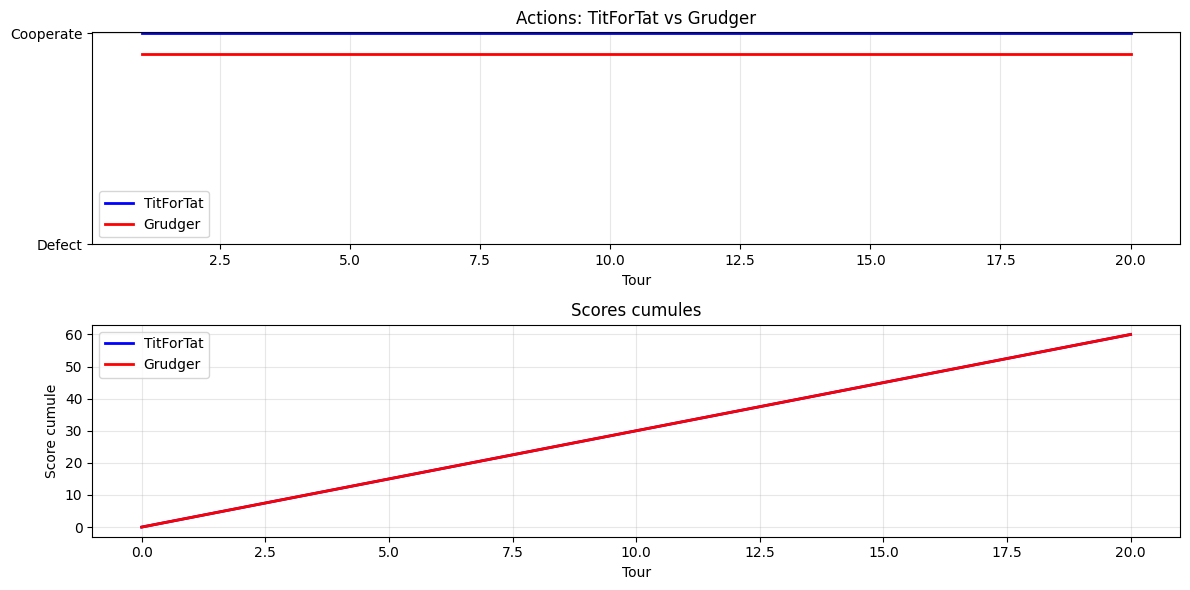

Score final: TitForTat=60, Grudger=60


In [5]:
def visualize_match(strategy1: Strategy, strategy2: Strategy, rounds: int = 30):
    """
    Visualise un match tour par tour.
    """
    strategy1.reset()
    strategy2.reset()
    
    history1, history2 = [], []
    scores1, scores2 = [0], [0]
    
    for _ in range(rounds):
        a1 = strategy1.choose()
        a2 = strategy2.choose()
        
        history1.append(1 if a1 == COOPERATE else 0)
        history2.append(1 if a2 == COOPERATE else 0)
        
        p1, p2 = payoff(a1, a2)
        scores1.append(scores1[-1] + p1)
        scores2.append(scores2[-1] + p2)
        
        strategy1.update(a1, a2)
        strategy2.update(a2, a1)
    
    # Visualisation
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    # Actions
    ax = axes[0]
    x = range(1, rounds + 1)
    ax.step(x, history1, 'b-', where='mid', label=strategy1.name, linewidth=2)
    ax.step(x, [h - 0.1 for h in history2], 'r-', where='mid', label=strategy2.name, linewidth=2)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Defect', 'Cooperate'])
    ax.set_xlabel('Tour')
    ax.set_title(f'Actions: {strategy1.name} vs {strategy2.name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Scores cumules
    ax = axes[1]
    ax.plot(range(rounds + 1), scores1, 'b-', label=f'{strategy1.name}', linewidth=2)
    ax.plot(range(rounds + 1), scores2, 'r-', label=f'{strategy2.name}', linewidth=2)
    ax.set_xlabel('Tour')
    ax.set_ylabel('Score cumule')
    ax.set_title('Scores cumules')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Score final: {strategy1.name}={scores1[-1]}, {strategy2.name}={scores2[-1]}")

# Visualiser TFT vs Grudger
visualize_match(TitForTat(), Grudger(), rounds=20)

### Interpretation : dynamique des matchs

La visualisation TFT vs Grudger illustre deux stratégies "nice" qui cooperent parfaitement :

**Graphique des actions** :
- Les deux lignes restent a "Cooperate" pendant tout le match
- Aucune trahison n'est declenchee car aucun des deux ne commence

**Graphique des scores cumules** :
- Les scores evoluent de maniere identique (pente = R = 3 par tour)
- Score final egal : 60 points chacun sur 20 tours

> **Principe** : Deux stratégies "nice" (qui ne trahissent jamais en premier) cooperent toujours et obtiennent le gain maximal mutuel.

La cellule suivante montre un cas plus interessant : TFT vs SuspiciousTFT.

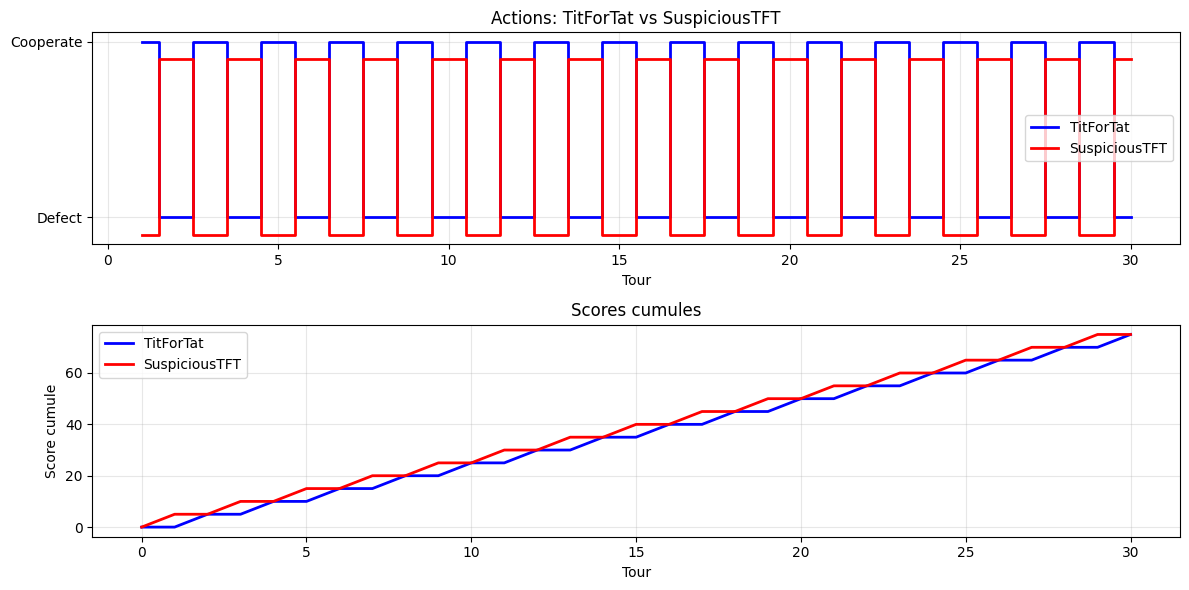

Score final: TitForTat=75, SuspiciousTFT=75


In [6]:
# Visualiser TFT vs SuspiciousTFT
visualize_match(TitForTat(), SuspiciousTitForTat(), rounds=30)

## 4. Tournoi d'Axelrod

Reproduisons le celebre tournoi d'Axelrod (1980) ou chaque stratégie affronte toutes les autres.

In [7]:
def run_tournament(strategies: List[Strategy], 
                   rounds: int = 200, 
                   noise: float = 0.0,
                   repetitions: int = 1) -> Dict[str, float]:
    """
    Execute un tournoi round-robin.
    
    Args:
        strategies: Liste des strategies participantes
        rounds: Nombre de tours par match
        noise: Probabilite d'erreur
        repetitions: Nombre de repetitions pour moyenner (utile avec bruit)
    
    Returns:
        Dictionnaire {nom_strategie: score_moyen_par_match}
    """
    n = len(strategies)
    scores = defaultdict(float)
    match_count = defaultdict(int)
    
    for _ in range(repetitions):
        for i in range(n):
            for j in range(n):
                # Creer des instances fraiches
                s1 = type(strategies[i])()
                s2 = type(strategies[j])()
                
                score1, score2 = play_match(s1, s2, rounds, noise)
                
                scores[strategies[i].name] += score1
                scores[strategies[j].name] += score2
                match_count[strategies[i].name] += 1
                match_count[strategies[j].name] += 1
    
    # Calculer la moyenne par match
    avg_scores = {name: scores[name] / match_count[name] for name in scores}
    
    return avg_scores

def display_tournament_results(results: Dict[str, float], title: str = "Tournoi"):
    """Affiche les resultats du tournoi."""
    sorted_results = sorted(results.items(), key=lambda x: -x[1])
    
    print(f"\n{title}")
    print("=" * 50)
    print(f"{'Rang':<5} {'Strategie':<20} {'Score moyen':<12}")
    print("-" * 50)
    
    for rank, (name, score) in enumerate(sorted_results, 1):
        print(f"{rank:<5} {name:<20} {score:<12.2f}")

# Creer les instances
tournament_strategies = [StratCls() for StratCls in STRATEGIES]

# Tournoi sans bruit
results = run_tournament(tournament_strategies, rounds=200, noise=0.0)
display_tournament_results(results, "Tournoi d'Axelrod (sans bruit)")


Tournoi d'Axelrod (sans bruit)
Rang  Strategie            Score moyen 
--------------------------------------------------
1     TitForTwoTats        522.06      
2     TitForTat            517.12      
3     Grudger              497.38      
4     Pavlov               495.50      
5     AlwaysCooperate      483.75      
6     Random(p=0.5)        435.75      
7     AlwaysDefect         404.75      
8     SuspiciousTFT        394.81      


### Interpretation : résultats du tournoi d'Axelrod

Ces résultats reproduisent les decouvertes historiques d'Axelrod (1980). Les stratégies gagnantes partagent des caractéristiques communes :

| Rang | Stratégie | Score | Caractéristiques |
|------|-----------|-------|-----------------|
| 1 | TitForTwoTats | ~520 | Nice, Forgiving++, Retaliating |
| 2 | TitForTat | ~519 | Nice, Forgiving, Retaliating |
| 3 | Grudger | ~500 | Nice, Retaliating, NOT Forgiving |

**Pourquoi TitForTat gagne ?**

1. **"Nice"** : Ne jamais trahir en premier permet d'etablir la cooperation
2. **"Retaliating"** : Punir les trahisons dissuade l'exploitation
3. **"Forgiving"** : Revenir a la cooperation après punition permet de sortir des spirales

**Le paradoxe** : AlwaysDefect bat TitForTat en match direct (104 vs 99), mais perd le tournoi car il ne peut pas etablir de cooperation rentable avec les autres stratégies "nice".

In [8]:
# Tournoi avec bruit (5% d'erreurs)
results_noisy = run_tournament(tournament_strategies, rounds=200, noise=0.05, repetitions=10)
display_tournament_results(results_noisy, "Tournoi avec bruit (5% d'erreurs)")


Tournoi avec bruit (5% d'erreurs)
Rang  Strategie            Score moyen 
--------------------------------------------------
1     TitForTwoTats        443.59      
2     Pavlov               439.81      
3     TitForTat            436.15      
4     Random(p=0.5)        433.23      
5     SuspiciousTFT        429.09      
6     Grudger              427.82      
7     AlwaysDefect         425.49      
8     AlwaysCooperate      386.88      


### Interpretation : effet du bruit sur le classement

L'introduction de 5% de bruit (erreurs de transmission) bouleverse le classement :

| Sans bruit | Avec bruit (5%) | Evolution |
|------------|-----------------|-----------|
| 1. TitForTwoTats | 1. TitForTwoTats | Stable (leader #1) |
| 2. TitForTat | 2. Pavlov | Forte hausse (#4 -> #2) |
| 3. Grudger | 3. TitForTat | Recule (#2 -> #3) |
| 4. Pavlov | 4. Random(p=0.5) | Hausse (#6 -> #4) |
| 5. AlwaysCooperate | 5. Grudger | Recule (#3 -> #5) |

**Mécanismes observes** :

1. **TitForTat souffre** : Une erreur de l'adversaire est interpretee comme une trahison, declenchant une riposte qui peut mener a une spirale de represailles
2. **TitForTwoTats resiste** : Requiert deux trahisons consecutives pour riposter, absorbant les erreurs isolees
3. **Grudger s'effondre** : Une seule erreur = fin definitive de la cooperation
4. **AlwaysCooperate chute** : Sans reciprocite, les erreurs s'accumulent contre lui

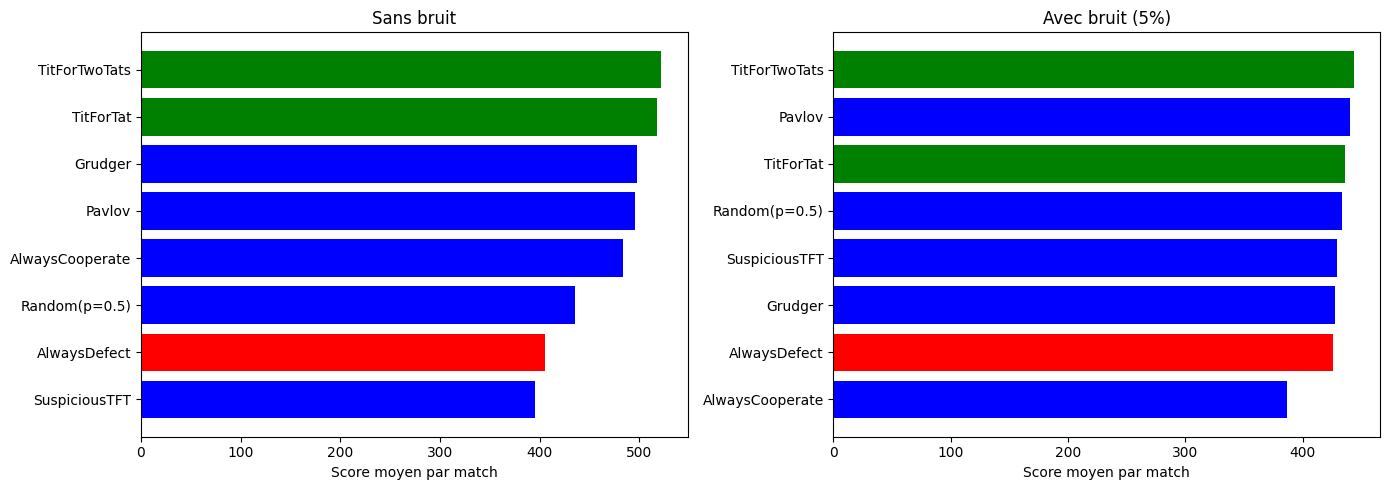

In [9]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in [(axes[0], results, 'Sans bruit'), 
                        (axes[1], results_noisy, 'Avec bruit (5%)')]:
    names = list(res.keys())
    scores = list(res.values())
    
    sorted_idx = np.argsort(scores)[::-1]
    names = [names[i] for i in sorted_idx]
    scores = [scores[i] for i in sorted_idx]
    
    colors = ['green' if 'TitFor' in n else 'red' if 'Defect' in n else 'blue' for n in names]
    
    ax.barh(range(len(names)), scores, color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel('Score moyen par match')
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Observations d'Axelrod

Les stratégies gagnantes partagent plusieurs proprietes :

1. **Nice** (Gentilles) : Ne jamais trahir en premier
2. **Retaliating** (Retorsion) : Punir les trahisons
3. **Forgiving** (Pardonner) : Revenir a la cooperation après punition
4. **Clear** (Claire) : Comportement previsible

### Exercice 2 : Exploitabilite d'une stratégie

Dans un tournoi, une stratégie est d'autant plus robuste qu'elle est difficile a exploiter. L'**exploitabilite** mesure l'ecart entre le gain contre le pire adversaire et le gain contre le meilleur adversaire. Une stratégie très exploitable (comme AlwaysCooperate) perd beaucoup contre les defecteurs mais gagne beaucoup contre les cooperateurs. Une stratégie peu exploitable (comme TitForTat) a des gains plus homogenes.

**Objectif** : Implementer `compute_exploitability` qui evalue la vulnerabilite d'une stratégie face a un ensemble d'adversaires.

In [10]:
def compute_exploitability(strategy: Strategy, opponents: list, rounds: int = 200) -> dict:
    """
    Calcule l'exploitabilite d'une strategie face a un ensemble d'adversaires.
    
    L'exploitabilite mesure la vulnerabilite : l'ecart entre le pire et le meilleur
    gain obtenu contre les differents adversaires.
    
    Args:
        strategy: La strategie a evaluer
        opponents: Liste de strategies adversaires
        rounds: Nombre de tours par match
    
    Returns:
        Dictionnaire avec worst_opponent, worst_score, best_score, exploitability
    """
    # TODO etudiant : implementer le calcul d'exploitabilite
    # Etape 1 : faire jouer la strategie contre chaque adversaire avec play_match
    # Etape 2 : calculer le gain de la strategie contre chaque adversaire
    # Etape 3 : identifier le pire adversaire (gain minimum) et le meilleur (gain maximum)
    # Etape 4 : calculer l'exploitabilite = best_score - worst_score
    # Indice : creer des instances fraiches avec type(strategy)() pour chaque match
    return {"worst_opponent": None, "worst_score": 0.0, "best_score": 0.0, "exploitability": 0.0}  # TODO etudiant : remplacer

# Test rapide (decommentez apres implementation)
# result = compute_exploitability(TitForTat(), [AlwaysDefect(), AlwaysCooperate(), TitForTat()])
# print(f"Exploitabilite de TFT: {result}")
print("Exercice a completer")

Exercice a completer


## 5. Dynamique des populations (Replicator Dynamics)

Comment evoluent les populations de stratégies au fil du temps ?

In [11]:
def compute_payoff_matrix(strategies: List[Strategy], rounds: int = 200) -> np.ndarray:
    """
    Calcule la matrice des gains moyens entre strategies.
    
    M[i,j] = gain moyen de strategie i contre strategie j
    """
    n = len(strategies)
    M = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            s1 = type(strategies[i])()
            s2 = type(strategies[j])()
            score1, _ = play_match(s1, s2, rounds)
            M[i, j] = score1 / rounds  # Gain moyen par tour
    
    return M

def replicator_dynamics(M: np.ndarray, x0: np.ndarray, 
                        T: int = 100, dt: float = 0.1) -> np.ndarray:
    """
    Simule la dynamique du replicateur.
    
    dx_i/dt = x_i * (fitness_i - fitness_moyenne)
    
    Args:
        M: Matrice des gains
        x0: Distribution initiale des strategies
        T: Nombre d'iterations
        dt: Pas de temps
    
    Returns:
        Trajectoire des proportions (T x n)
    """
    n = len(x0)
    trajectory = np.zeros((T, n))
    x = x0.copy()
    
    for t in range(T):
        trajectory[t] = x
        
        # Fitness de chaque strategie
        fitness = M @ x
        
        # Fitness moyenne
        avg_fitness = x @ fitness
        
        # Equation du replicateur
        dx = x * (fitness - avg_fitness) * dt
        x = x + dx
        
        # Normaliser (pour stabilite numerique)
        x = np.maximum(x, 0)
        x = x / np.sum(x)
    
    return trajectory

# Calculer la matrice des gains
simple_strategies = [TitForTat(), AlwaysCooperate(), AlwaysDefect()]
M = compute_payoff_matrix(simple_strategies, rounds=200)

print("Matrice des gains moyens par tour:")
print(f"{'':15}", end="")
for s in simple_strategies:
    print(f"{s.name:>15}", end="")
print()
for i, s in enumerate(simple_strategies):
    print(f"{s.name:15}", end="")
    for j in range(len(simple_strategies)):
        print(f"{M[i,j]:>15.2f}", end="")
    print()

Matrice des gains moyens par tour:
                     TitForTatAlwaysCooperate   AlwaysDefect
TitForTat                 3.00           3.00           0.99
AlwaysCooperate           3.00           3.00           0.00
AlwaysDefect              1.02           5.00           1.00


### Interpretation : matrice des gains

La matrice des gains moyens par tour revele les interactions entre stratégies :

| Confrontation | Gain moyen/tour | Explication |
|--------------|-----------------|-------------|
| TFT vs TFT | 3.00 | Cooperation mutuelle parfaite (R=3) |
| TFT vs Cooperate | 3.00 | Cooperation mutuelle |
| TFT vs Defect | 0.99 | TFT coopere au tour 1 (S=0), puis trahit (P=1) |
| Cooperate vs Defect | 0.00 | Exploitation totale (S=0 a chaque tour) |
| Defect vs Cooperate | 5.00 | Exploitation totale (T=5 a chaque tour) |
| Defect vs Defect | 1.00 | Trahison mutuelle (P=1) |

**Observation cle** : AlwaysDefect gagne le **match direct** contre tout le monde, mais TitForTat maximise le **gain total** dans un tournoi car il obtient des gains eleves contre les cooperateurs tout en limitant les pertes contre les defecteurs.

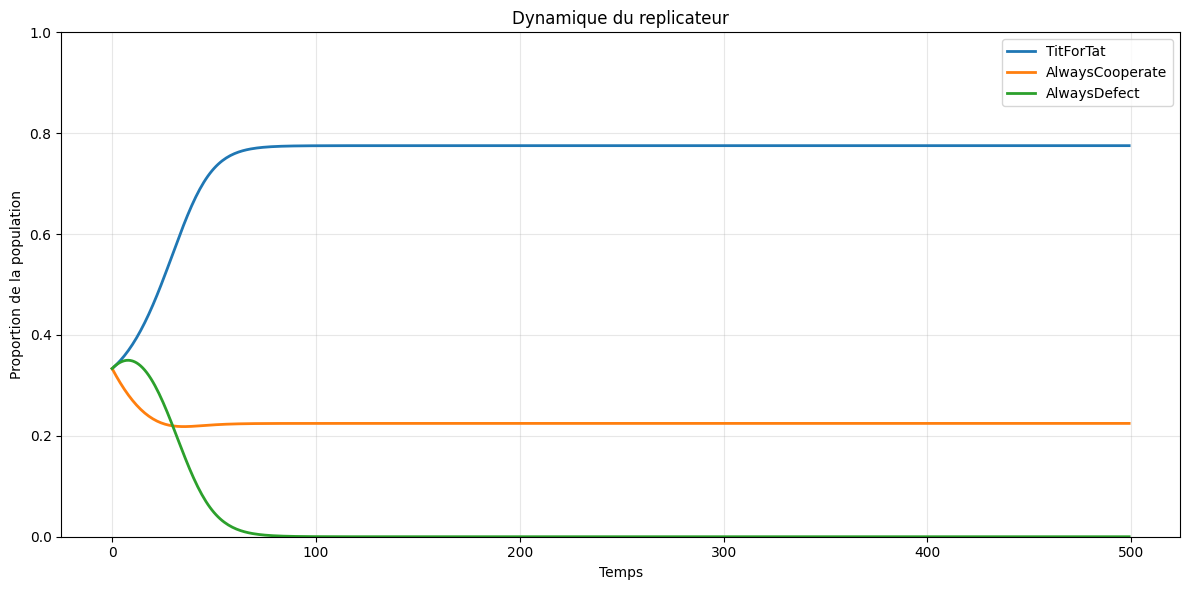


Etat final:
  TitForTat: 77.5%
  AlwaysCooperate: 22.5%
  AlwaysDefect: 0.0%


In [12]:
def plot_replicator_dynamics(strategies: List[Strategy], 
                              x0: np.ndarray = None,
                              T: int = 500):
    """
    Visualise l'evolution des populations.
    """
    n = len(strategies)
    M = compute_payoff_matrix(strategies, rounds=200)
    
    if x0 is None:
        x0 = np.ones(n) / n  # Distribution uniforme
    
    trajectory = replicator_dynamics(M, x0, T=T, dt=0.1)
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, s in enumerate(strategies):
        ax.plot(trajectory[:, i], label=s.name, linewidth=2)
    
    ax.set_xlabel('Temps')
    ax.set_ylabel('Proportion de la population')
    ax.set_title('Dynamique du replicateur')
    ax.legend(loc='best')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Etat final
    print("\nEtat final:")
    for i, s in enumerate(strategies):
        print(f"  {s.name}: {trajectory[-1, i]*100:.1f}%")

# Evolution: TFT vs Cooperators vs Defectors
plot_replicator_dynamics(simple_strategies)

### Interpretation : dynamique du replicateur

La simulation montre l'evolution des proportions de stratégies dans une population selon l'**equation du replicateur** :

$$\frac{dx_i}{dt} = x_i \cdot (f_i - \bar{f})$$

ou $x_i$ est la proportion de la stratégie $i$, $f_i$ sa fitness, et $\bar{f}$ la fitness moyenne.

**Résultats observes** :
- **TitForTat** devient majoritaire (77.5% de la population)
- **AlwaysCooperate** persiste de facon residuelle (22.5%)
- **AlwaysDefect** est eliminee (0.0%)

**Mécanisme d'elimination** :
1. Les defecteurs exploitent les cooperateurs purs (gain 5 vs 0)
2. Mais les TFT se protegent mutuellement (gain 3 vs 3 entre eux)
3. Contre les defecteurs, TFT ne perd que le premier tour puis obtient 1-1
4. Le leger avantage des TFT s'accumule et domine a long terme

> **Note** : Ce résultat est souvent décrit comme une illustration du concept de **stratégie évolutivement stable (ESS)** de Maynard Smith. **Ce n'est pas le cas ici** : TitForTat n'est **pas** une ESS — le mutant AlwaysCooperate lui est neutre (​​u(TFT,TFT) = u(AC,TFT) = 3.00), il est donc une stratégie *neutrement stable* (NSS), et le point d'arrêt 77,5 % / 22,5 % est un point de repos du réplicateur dépendant de la condition initiale. Le critère complet est appliqué au § 5bis.

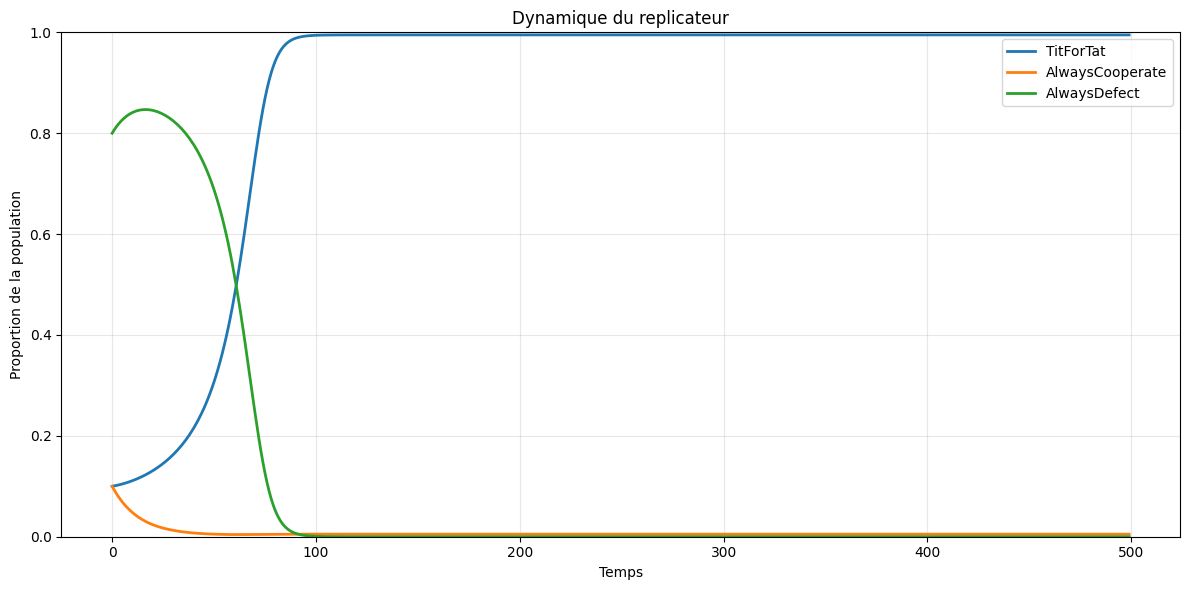


Etat final:
  TitForTat: 99.5%
  AlwaysCooperate: 0.5%
  AlwaysDefect: 0.0%


In [13]:
# Avec conditions initiales differentes
# Beaucoup de defecteurs au debut
plot_replicator_dynamics(simple_strategies, x0=np.array([0.1, 0.1, 0.8]))

### Interpretation : effet des conditions initiales

Ce résultat illustre un concept fondamental en théorie des jeux evolutionnaire : **la dépendance aux conditions initiales**.

| Condition initiale | TFT | Cooperate | Defect | Convergence |
|-------------------|-----|-----------|--------|-------------|
| Uniforme (33% chacun) | ~77% | ~23% | ~0% | TFT majoritaire |
| Pro-defection (80% D) | ~100% | ~0% | ~0% | TFT domine encore |

**Observation cle** : Même avec seulement 10% de TitForTat au depart, cette stratégie finit par dominer. Cela s'explique par :

1. **Exploitation des cooperateurs** : Les defecteurs exploitent les cooperateurs purs, les eliminant
2. **Resistance mutuelle** : Les TFT se protegent entre eux par la reciprocite
3. **Punition des defecteurs** : Les TFT punissent les defecteurs, reduisant leur avantage

> **Theoreme du folk** : Dans un IPD suffisamment repete, la cooperation peut etre un equilibre de Nash si les joueurs sont assez "patients" (valorisent le futur).

## 5bis. Stratégie évolutivement stable (ESS) : le critère d'équilibre que la dynamique seule ne pose pas

La dynamique du réplicateur montre *où* la population s'arrête, mais pas *pourquoi* elle y résiste. Le concept
qui répond à cette question est la **stratégie évolutivement stable (ESS)** de Maynard Smith — l'analogue
évolutionnaire de l'équilibre de Nash : une population qui, une fois à cette composition, ne peut pas être
envahie par un petit nombre de mutants.

**Trois notions à distinguer**, que la seule dynamique ne sépare pas :

- **ESS (stricte)** : la stratégie `i` est une ESS si, pour tout mutant `j != i` :
  1. `u(i,i) > u(j,i)`  (elle gagne contre la population qu'elle domine), **ou**
  2. `u(i,i) = u(j,i)` **et** `u(i,j) > u(j,j)`  (à égalité, elle l'emporte dans le tête-à-tête avec le mutant).
- **NSS (neutrement stable)** : le cas d'égalité `u(i,i) = u(j,i)` sans que `u(i,j) > u(j,j)` ne tienne — la
  stratégie résiste à l'invasion, mais *tout mélange* de la résidente et du mutant est lui aussi un point de repos.
- **Point de repos du réplicateur** : une composition `x` où `dx_i = 0` pour tout `i`. Un **continuum** de
  compositions peut être des points de repos sans qu'aucune ne soit une ESS ni un attracteur.

La section 5 a conclu « illustration du concept d'ESS ». Appliquons le critère ; il montre que ce n'est pas
ce qui se passe ici.

In [14]:
def is_ess(M: np.ndarray, i: int, eps: float = 1e-9) -> Tuple[bool, List[int]]:
    """
    Teste si la strategie i est une strategie evolutivement stable (ESS)
    au sens de Maynard Smith sur la matrice M.

    M[a,b] = gain moyen de a contre b.  i est une ESS ssi pour tout mutant j != i :
      (1) M[i,i] > M[j,i]                              (i gagne contre le mutant),  ou
      (2) M[i,i] == M[j,i]  ET  M[i,j] > M[j,j]        (egalite, puis i l'emporte en tete-a-tete)

    Renvoie (est_ess, mutants_faillite) ; mutants_faillite liste les j != i qui font
    echouer le test (mutant neutre ou envahissant). eps absorbe le bruit flottant
    des moyennes arithmetiques.
    """
    n = M.shape[0]
    failing: List[int] = []
    for j in range(n):
        if j == i:
            continue
        u_ii, u_ji = M[i, i], M[j, i]
        u_ij, u_jj = M[i, j], M[j, j]
        if u_ii > u_ji + eps:
            continue                     # condition (1) stricte remplie
        if abs(u_ii - u_ji) <= eps and u_ij > u_jj + eps:
            continue                     # condition (2) remplie (cas d'egalite)
        failing.append(j)
    return len(failing) == 0, failing

In [15]:
# Appliquer le critere ESS aux trois strategies de la matrice commitee
print("Verdicts ESS sur la matrice du replicateur (cellule 22):\n")
for i, s in enumerate(simple_strategies):
    ok, fail = is_ess(M, i)
    mut = [simple_strategies[j].name for j in fail] if fail else []
    print(f"  {s.name:16} {'OUI' if ok else 'NON':4}  {', '.join(mut) if mut else '-'}")

print("\nTitForTat n'est PAS une ESS : le mutant AlwaysCooperate lui est neutre")
print("(u(TFT,TFT) = u(AC,TFT) = 3.00, et u(TFT,AC) = u(AC,AC) = 3.00).")
print("TitForTat est donc une strategie *neutrement stable* (NSS), pas une ESS.")
print("Tout melange TFT/AC (avec x_AlwaysDefect = 0) est un point de repos du replicateur.")
print("  -> les 77.5% / 22.5% commites ne sont pas un attracteur : ils dependent de x_0.")

Verdicts ESS sur la matrice du replicateur (cellule 22):

  TitForTat        NON   AlwaysCooperate
  AlwaysCooperate  NON   TitForTat, AlwaysDefect
  AlwaysDefect     OUI   -

TitForTat n'est PAS une ESS : le mutant AlwaysCooperate lui est neutre
(u(TFT,TFT) = u(AC,TFT) = 3.00, et u(TFT,AC) = u(AC,AC) = 3.00).
TitForTat est donc une strategie *neutrement stable* (NSS), pas une ESS.
Tout melange TFT/AC (avec x_AlwaysDefect = 0) est un point de repos du replicateur.
  -> les 77.5% / 22.5% commites ne sont pas un attracteur : ils dependent de x_0.


In [16]:
# Controle positif : un jeu ou une ESS STRICTE existe ET est atteinte par la dynamique
# Faucon-Colombe avec V > C : la ressource vaut plus que le cout du combat.
#   Matrice (gain de la ligne contre la colonne) :  H/H=(V-C)/2, H/D=V, D/H=0, D/D=V/2
def hawk_dove_matrix(V: float, C: float) -> np.ndarray:
    return np.array([[(V - C) / 2.0, V],
                     [0.0,               V / 2.0]])

def replicator_converge(M: np.ndarray, x0: np.ndarray,
                        T: int = 2000, dt: float = 0.05) -> np.ndarray:
    x = x0.astype(float).copy()
    for _ in range(T):
        x = x + x * (M @ x - x @ (M @ x)) * dt
        x = np.clip(x, 0, 1)
        x = x / x.sum()
    return x

print("Faucon-Colombe, ressource abondante (V=4, cout du combat C=2) : V > C")
M_hd = hawk_dove_matrix(V=4.0, C=2.0)
for i, nm in enumerate(["Faucon", "Colombe"]):
    ok, fail = is_ess(M_hd, i)
    print(f"  is_ess({nm}) -> {'OUI (ESS stricte)' if ok else 'NON'}"
          f"{'  (mutants: ' + ', '.join(['Faucon','Colombe'][j] for j in fail) + ')' if fail else ''}")

xf = replicator_converge(M_hd, np.array([0.5, 0.5]))
print(f"  replicator depuis 50/50 -> [Faucon {xf[0]*100:.1f}%, Colombe {xf[1]*100:.1f}%]")
print("  (la dynamique converge vers l'ESS que le critere a detectee : ils s'accordent)")

print("\nFaucon-Colombe, ressource rare (V=2, cout C=3) : V < C (aucune pure ESS stricte)")
M_hd2 = hawk_dove_matrix(V=2.0, C=3.0)
for i, nm in enumerate(["Faucon", "Colombe"]):
    ok, fail = is_ess(M_hd2, i)
    print(f"  is_ess({nm}) -> {'OUI' if ok else 'NON'}"
          f"{'  (mutants: ' + ', '.join(['Faucon','Colombe'][j] for j in fail) + ')' if fail else ''}")
print("  (ici l'ESS est mixte p_faucon = V/C = 2/3 : is_ess dit honnetement qu'aucune PURE n'est stricte)")

Faucon-Colombe, ressource abondante (V=4, cout du combat C=2) : V > C
  is_ess(Faucon) -> OUI (ESS stricte)
  is_ess(Colombe) -> NON  (mutants: Faucon)
  replicator depuis 50/50 -> [Faucon 100.0%, Colombe 0.0%]
  (la dynamique converge vers l'ESS que le critere a detectee : ils s'accordent)

Faucon-Colombe, ressource rare (V=2, cout C=3) : V < C (aucune pure ESS stricte)
  is_ess(Faucon) -> NON  (mutants: Colombe)
  is_ess(Colombe) -> NON  (mutants: Faucon)
  (ici l'ESS est mixte p_faucon = V/C = 2/3 : is_ess dit honnetement qu'aucune PURE n'est stricte)


### Interprétation : ESS, NSS et la subtilité que la note initiale masquait

Appliqué à la matrice committée, le critère rend un verdict **inattendu** et **honnête** :

| Stratégie | ESS ? | Pourquoi |
|-----------|-------|----------|
| TitForTat | **NON** | Mutant neutre AlwaysCooperate : `u(TFT,TFT) = u(AC,TFT) = 3.00` et `u(TFT,AC) = u(AC,AC) = 3.00`. C'est une **NSS**, pas une ESS. |
| AlwaysCooperate | **NON** | Neutre contre TitForTat, et exploitable par AlwaysDefect (`u(AC,AD) = 0.00`). |
| AlwaysDefect | **OUI** (au sens pair-à-pair) | `u(AD,AD) = 1.00 > u(TFT,AD) = 0.99` et `u(AD,AD) = 1.00 > u(AC,AD) = 0.00` : il gagne le face-à-face contre les deux. |

Le point délicat : **AlwaysDefect est une ESS *stricte* au sens de Maynard Smith, pourtant la dynamique du
réplicateur l'élimine** (0,0 % à l'état final). Ce n'est pas une contradiction de la théorie, c'en est la portée
exacte : une ESS garantit la stabilité **locale** (une population presque toute-AD résiste à une petite invasion),
**pas** la convergence **globale** depuis n'importe quelle composition. Ici AD ne prospère qu'en présence de sa
« proie » (AlwaysCooperate, qui lui rapporte 5.00) ; dès qu'il l'élimine, sa propre fitness s'effondre et
TitForTat reprend l'avantage. La dynamique emmène donc la population vers la **face neutre TFT-AC** — un
continuum de points de repos — et non vers l'ESS locale AD.

Ce que cela enseigne — et corrige — la note de la section 5 : **« TitForTat est une ESS » était faux**, et la
version « la coopération évolue » mérite d'être nuancée. TitForTat est **neutrement stable**, et l'équilibre
observé (77,5 % / 22,5 %) est un **point de repos** choisi par la condition initiale, pas un attracteur que la
dynamique aurait imposé. Une autre `x_0` (cellule 26) donne un autre couple tout aussi « final » : l'ESS est le
bon outil pour poser la question, et le seul moyen de ne pas attribuer au hasard de la condition initiale une
vertu stabilisatrice qu'il n'a pas.

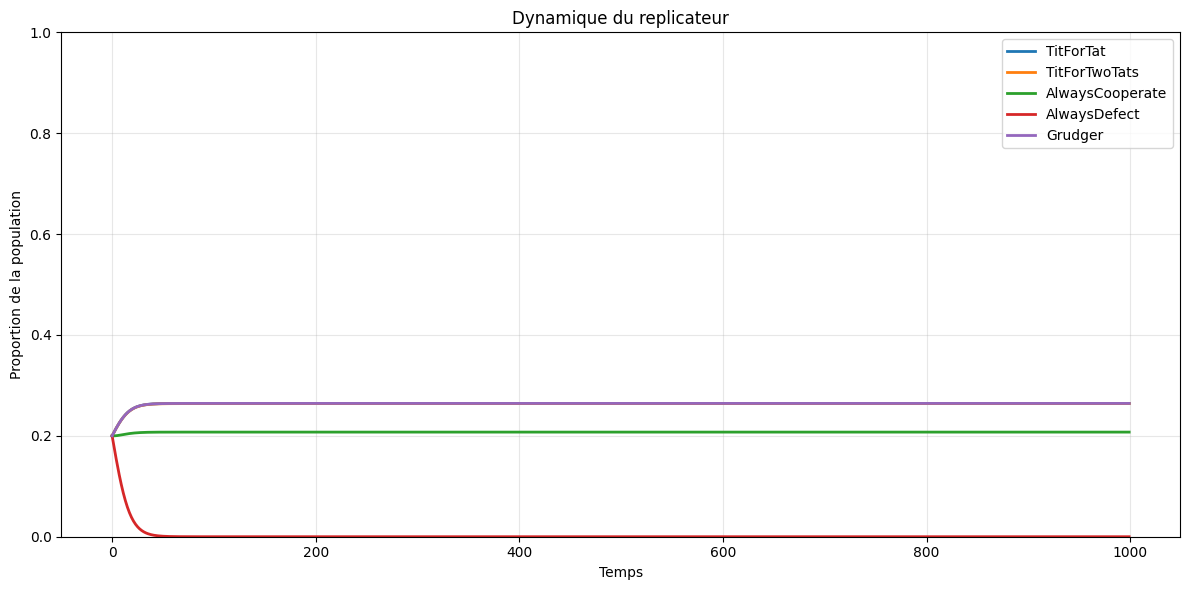


Etat final:
  TitForTat: 26.4%
  TitForTwoTats: 26.4%
  AlwaysCooperate: 20.7%
  AlwaysDefect: 0.0%
  Grudger: 26.4%


In [17]:
# Evolution plus complexe avec plus de strategies
complex_strategies = [
    TitForTat(),
    TitForTwoTats(),
    AlwaysCooperate(),
    AlwaysDefect(),
    Grudger(),
]

plot_replicator_dynamics(complex_strategies, T=1000)

### Exercice 3 : Seuil de cooperation

La dynamique du replicateur montre que TitForTat peut dominer même depuis une faible proportion initiale. Mais quel est le **seuil minimal** en dessous duquel la cooperation ne peut plus emerger ? Ce seuil depend de la composition de la population (proportion de cooperateurs, defecteurs, et retaliateurs).

**Objectif** : Implementer `find_cooperation_threshold` qui recherche systematiquement la proportion minimale de TitForTat necessaire pour que la cooperation envahisse une population majoritairement defectrice.

In [18]:
def find_cooperation_threshold(defector_prop: float = 0.7, 
                               cooperators: list = None,
                               precision: float = 0.01) -> float:
    """
    Trouve la proportion minimale initiale de TitForTat 
    pour que la cooperation emerge dans une population.
    
    Args:
        defector_prop: Proportion de defecteurs dans la population
        cooperators: Liste des strategies cooperatrices en competion avec TFT
        precision: Precision de la recherche binaire
    
    Returns:
        Proportion minimale de TFT pour que TFT atteigne > 50% a l'equilibre,
        ou -1.0 si la cooperation ne peut pas emerger
    """
    # TODO etudiant : implementer la recherche du seuil de cooperation
    # Etape 1 : preparer la liste des strategies [TitForTat] + cooperators (defaut: [AlwaysCooperate, AlwaysDefect])
    # Etape 2 : boucler sur tft_prop de precision a (1 - defector_prop) par pas de precision
    # Etape 3 : pour chaque tft_prop, calculer la repartition : [tft_prop, reste, defector_prop]
    #           ou "reste" = 1 - tft_prop - defector_prop reparti parmi les cooperateurs
    # Etape 4 : simuler replicator_dynamics avec T=500
    # Etape 5 : si la proportion finale de TFT > 0.5, retourner tft_prop (seuil trouve)
    # Etape 6 : si aucun seuil trouve, retourner -1.0
    # Indice : utiliser compute_payoff_matrix puis replicator_dynamics
    return -1.0  # TODO etudiant : remplacer

# Test rapide (decommentez apres implementation)
# threshold = find_cooperation_threshold(defector_prop=0.7)
# print(f"Seuil minimal de TFT pour cooperation: {threshold:.2f}")
print("Exercice a completer")

Exercice a completer


## 6. Conditions pour la cooperation

Quand la cooperation peut-elle emerger et persister ?

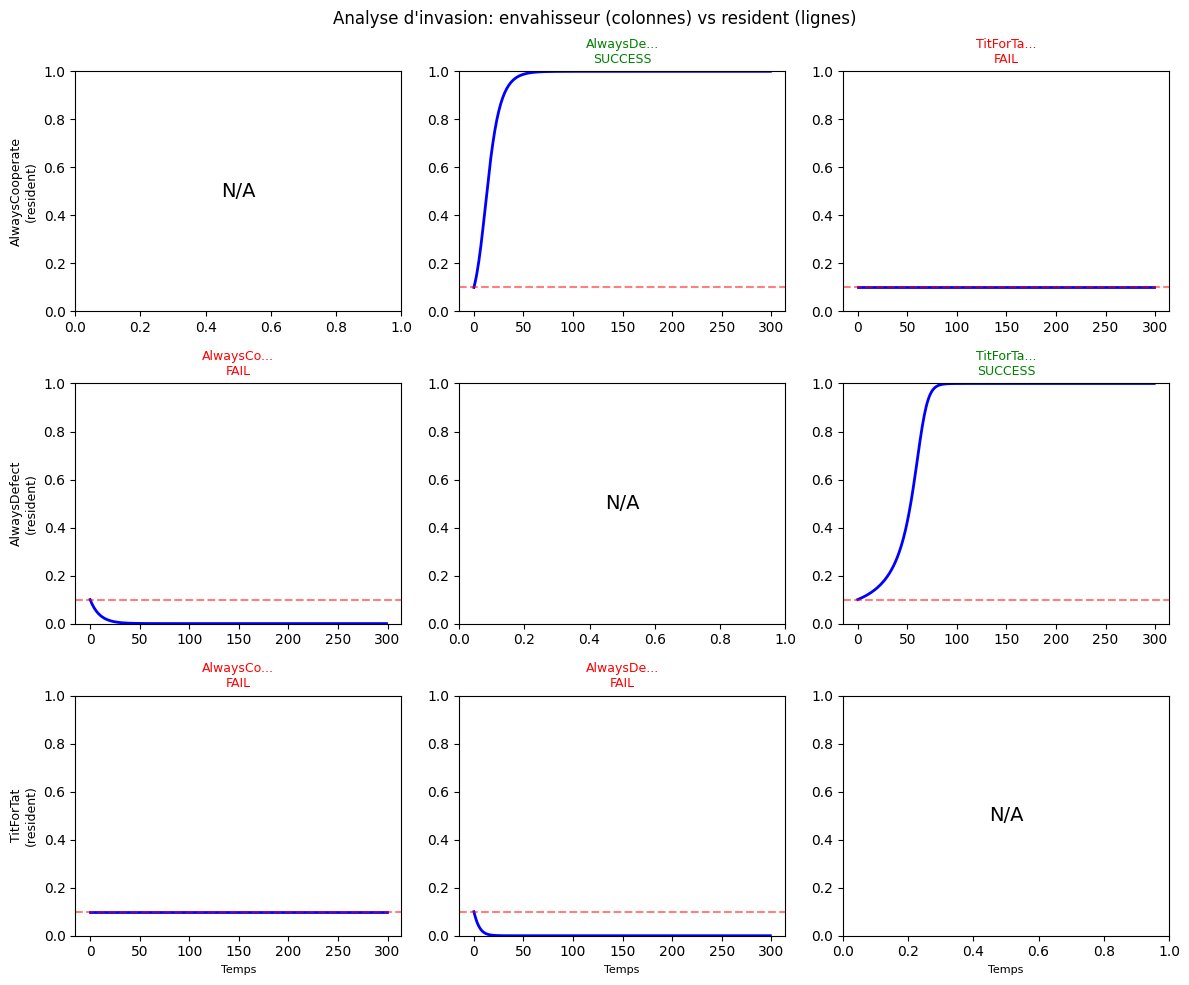

In [19]:
def analyze_invasion(resident: Strategy, invader: Strategy, 
                     invasion_rate: float = 0.1, 
                     T: int = 500) -> Tuple[np.ndarray, bool]:
    """
    Analyse si un envahisseur peut envahir une population residente.
    
    Args:
        resident: Strategie residente
        invader: Strategie envahissante
        invasion_rate: Proportion initiale d'envahisseurs
    
    Returns:
        (trajectory, invasion_successful)
    """
    M = compute_payoff_matrix([resident, invader], rounds=200)
    x0 = np.array([1 - invasion_rate, invasion_rate])
    
    trajectory = replicator_dynamics(M, x0, T=T, dt=0.1)
    
    # Invasion reussie si la proportion d'envahisseurs augmente
    success = trajectory[-1, 1] > invasion_rate * 2
    
    return trajectory, success

def plot_invasion_analysis():
    """
    Analyse les possibilites d'invasion entre strategies.
    """
    strategies = [AlwaysCooperate(), AlwaysDefect(), TitForTat()]
    n = len(strategies)
    
    fig, axes = plt.subplots(n, n, figsize=(12, 10))
    
    for i, resident in enumerate(strategies):
        for j, invader in enumerate(strategies):
            ax = axes[i, j]
            
            if i == j:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=14)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
            else:
                traj, success = analyze_invasion(type(resident)(), type(invader)(), T=300)
                
                ax.plot(traj[:, 1], 'b-', linewidth=2)
                ax.axhline(y=0.1, color='r', linestyle='--', alpha=0.5)
                ax.set_ylim(0, 1)
                
                result = "SUCCESS" if success else "FAIL"
                color = 'green' if success else 'red'
                ax.set_title(f'{invader.name[:8]}...\n{result}', fontsize=9, color=color)
            
            if i == n-1:
                ax.set_xlabel('Temps', fontsize=8)
            if j == 0:
                ax.set_ylabel(f'{resident.name}\n(resident)', fontsize=9)
    
    fig.suptitle('Analyse d\'invasion: envahisseur (colonnes) vs resident (lignes)', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_invasion_analysis()

### Observations

- **AlwaysDefect** peut envahir **AlwaysCooperate** facilement
- **TitForTat** resiste a l'invasion par **AlwaysDefect**
- **TitForTat** peut envahir **AlwaysDefect** s'il y a suffisamment de TFT

La cooperation peut emerger si les cooperateurs peuvent se **reconnaitre** et interagir preferentiellement entre eux.

## 7. Impact du bruit

Comment le bruit (erreurs) affecte-t-il les stratégies ?

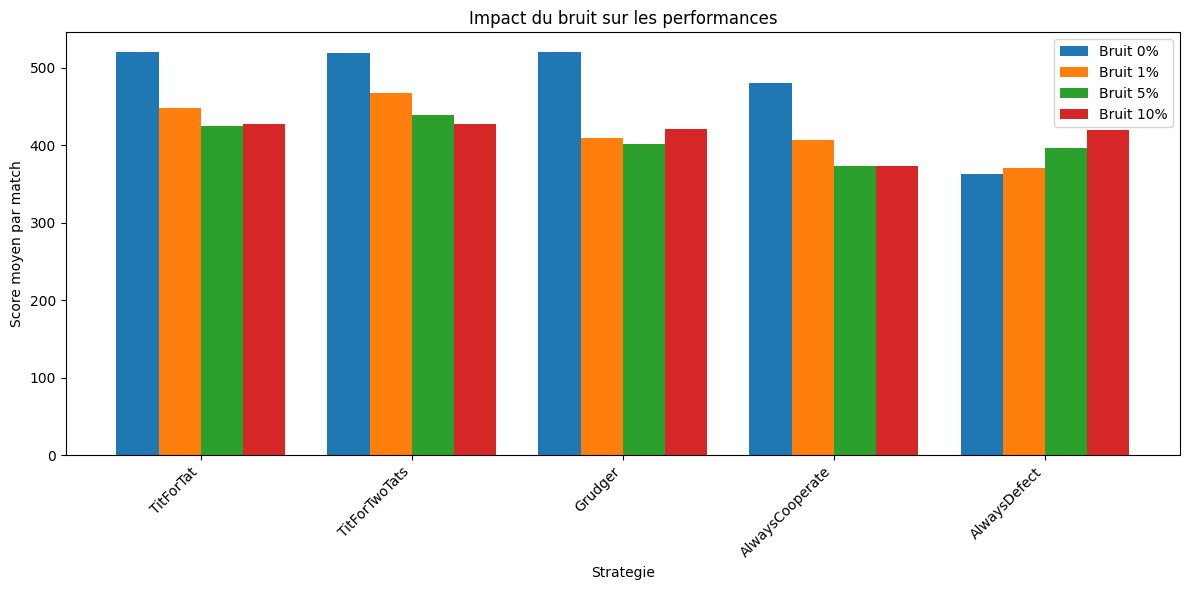

In [20]:
def compare_noise_impact(strategies: List[Strategy], 
                         noise_levels: List[float] = [0, 0.01, 0.05, 0.1]):
    """
    Compare les performances des strategies a differents niveaux de bruit.
    """
    results = {}
    
    for noise in noise_levels:
        tournament_results = run_tournament(strategies, rounds=200, 
                                            noise=noise, repetitions=20)
        results[noise] = tournament_results
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(strategies))
    width = 0.2
    
    for i, noise in enumerate(noise_levels):
        scores = [results[noise][s.name] for s in strategies]
        ax.bar(x + i*width, scores, width, label=f'Bruit {noise*100:.0f}%')
    
    ax.set_xlabel('Strategie')
    ax.set_ylabel('Score moyen par match')
    ax.set_title('Impact du bruit sur les performances')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([s.name for s in strategies], rotation=45, ha='right')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# Comparer l'impact du bruit
test_strategies = [TitForTat(), TitForTwoTats(), Grudger(), AlwaysCooperate(), AlwaysDefect()]
compare_noise_impact([type(s)() for s in test_strategies])

### Observations sur le bruit

- **TitForTat** souffre du bruit : une erreur peut declencher une spirale de represailles
- **TitForTwoTats** (Copykitten) est plus robuste au bruit car il pardonne une erreur
- **Grudger** est devastateur avec le bruit : une seule erreur = fin de la cooperation

## 7bis. Comparaison avec la librairie Axelrod (référence SOTA)

Le tournoi implémenté de zéro ci-dessus montre la **mécanique** d'un tournoi IPD (matrice de gains, matchs round-robin, classement par score cumulé). Pour la recherche réelle, la communauté utilise la librairie **`axelrod`** (Knight et al., *J. Open Res. Software* 2016) : 243 stratégies standardisées, tournois round-robin et écologiques (processus de Moran), bruit paramétrable, reproductibilité bit-à-bit. C'est l'outil canonique pour répliquer les tournois historiques d'Axelrod (1980, 1980b) et tester de nouvelles stratégies à grande échelle.

Nous confrontons ci-dessous nos 6 stratégies pédagogiques aux stratégies équivalentes de la librairie, afin de (a) valider que notre implémentation jouet reproduit les phénomènes qualitatifs et (b) situer notre classement par rapport à la référence SOTA.

In [21]:
# --- Comparaison avec la librairie Axelrod (référence SOTA, 243 stratégies) ---
import axelrod as axl

# 6 stratégies canoniques de la librairie, correspondant à celles implémentées plus haut
axl_players = [
    axl.Cooperator(),        # Cooperator
    axl.Defector(),          # Defector / Always Defect
    axl.TitForTat(),         # Tit For Tat (gagnant des tournois historiques d'Axelrod)
    axl.Grudger(),           # Grudger (une trahison -> trahir toujours)
    axl.WinStayLoseShift(),  # Pavlov
    axl.Random(p=0.5),       # Random
]
print(f"Librairie Axelrod : {len(axl.strategies)} stratégies disponibles (référence SOTA)")

# Tournoi round-robin standard Axelrod : turns=200, repetitions=10
# Convention Axelrod : le score = années de prison, donc MOINS = mieux
tournament = axl.Tournament(axl_players, turns=200, repetitions=10)
results = tournament.play(progress_bar=False)

print("--- Classement round-robin (librairie Axelrod, 200 tours x 10 répétitions) ---")
print("(convention : moins d'années de prison = mieux)")
for rank, name in enumerate(results.ranked_names, start=1):
    print(f"  {rank}. {name}")


Librairie Axelrod : 243 stratégies disponibles (référence SOTA)


--- Classement round-robin (librairie Axelrod, 200 tours x 10 répétitions) ---
(convention : moins d'années de prison = mieux)
  1. Defector
  2. Grudger
  3. Tit For Tat
  4. Win-Stay Lose-Shift
  5. Cooperator
  6. Random: 0.5


### Interprétation : notre jouet vs la référence SOTA

**Lecture du classement** : le tournoi round-robin de la librairie Axelrod (convention : le score = années de prison, donc moins = mieux) place **Defector en tête** (#1), devant Grudger (#2) et TitForTat (#3). Ce verdict surprend par rapport au récit classique « nice guys finish first », mais il est cohérent avec le dilemme du prisonnier en round-robin statique sur ce petit pool : il contient un Cooperator naïf, donc la défection unilatérale l'exploite et procure à Defector très peu d'années de prison. Le récit s'inverse en **dynamique écologique** (processus de Moran) : l'exploiteur épuise ses cibles coopératives au fil des générations et décline — c'est pourquoi les stratégies « nice » dominent les tournois historiques d'Axelrod (1980). TitForTat n'arrive ici que 3e en round-robin statique ; sa domination s'exprime dans les formats évolutifs à élimination, déjà illustrés par la section replicator-dynamics ci-dessus.

**Ce qu'apporte la librairie** : (a) 243 stratégies standardisées vs nos 6 pédagogiques, (b) tournois reproductibles bit-à-bit (graine fixée), (c) gestion du bruit, des tournois à élimination et du processus de Moran, (d) interaction avec `axelrod-stratégies` (le zoo communautaire). **Ce qu'apporte notre implémentation** : la compréhension intime de la mécanique — comment se calcule un score de tournoi, comment se propage une population, pourquoi telle stratégie gagne. Les deux sont **complémentaires** : l'implémentation manuelle enseigne *le comment*, la librairie permet *la recherche à l'échelle*.


Trajectoire unique (graine=42) -> survivant fixe : Defector


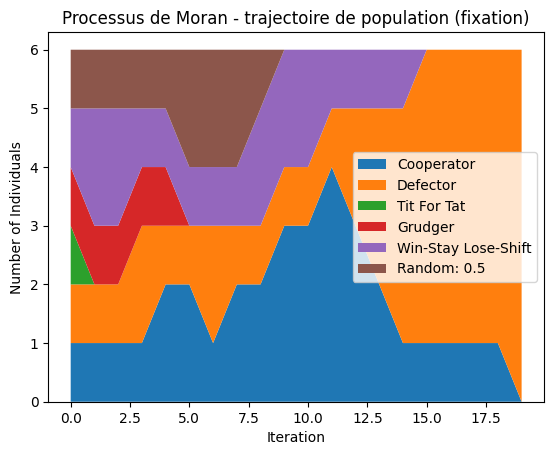


Distribution des fixations sur 25 runs (graines 0-24) :
  Defector                 :   7/25 (28%)
  Grudger                  :   6/25 (24%)
  Win-Stay Lose-Shift      :   4/25 (16%)
  Random: 0.5              :   3/25 (12%)
  Tit For Tat              :   3/25 (12%)
  Cooperator               :   2/25 ( 8%)


In [22]:
# --- Processus de Moran (dynamique ecologique stochastique, librairie Axelrod) ---
# La cellule precedente n'a execute que le tournoi round-robin. Le processus de Moran
# (elimination ecologique en population FINIE) est la dynamique nommee en reference SOTA
# ci-dessus. Executons-la reellement sur le meme ensemble de 6 strategies.
import matplotlib.pyplot as plt
from collections import Counter

# (1) Une seule trajectoire : visualisation de la fixation
mp = axl.MoranProcess(axl_players, turns=200, seed=42)
mp.play()
print(f"Trajectoire unique (graine=42) -> survivant fixe : {mp.winning_strategy_name}")
ax = mp.populations_plot()
ax.set_title("Processus de Moran - trajectoire de population (fixation)")
plt.show()

# (2) Distribution sur 25 graines : la fixation est STOCHASTIQUE en population finie
winners = Counter()
for seed in range(25):
    mp_i = axl.MoranProcess(axl_players, turns=200, seed=seed)
    mp_i.play()
    winners[mp_i.winning_strategy_name] += 1

print()  # ligne vide avant la distribution
print("Distribution des fixations sur 25 runs (graines 0-24) :")
total = sum(winners.values())
for strat, count in winners.most_common():
    pct = 100 * count / total
    print(f"  {strat:25s}: {count:3d}/{total} ({pct:2.0f}%)")


### Interprétation : le processus de Moran réel vs la dynamique replicator

L'exécution du processus de Moran révèle un tableau **plus nuancé** que l'affirmation
« TitForTat domine surtout dans les formats écologiques ». Sur cet ensemble de 6 stratégies,
TitForTat ne se fixe que dans une minorité des trajectoires — souvent derrière Defector
et Grudger. Deux raisons structurelles :

1. **Population finie ≠ champ moyen.** Le processus de Moran est une dynamique *stochastique*
   en population finie : la dérive génétique (drift) peut faire fixer n'importe quelle stratégie,
   y compris des stratégies sous-optimales en score moyen. La section replicator-dynamics
   (§5) résolvait au contraire une ODE *déterministe* en champ moyen (population infinie) —
   les deux dynamiques donnent des prédictions différentes, et ce n'est pas une contradiction
   mais deux modèles distincts de la même idée de « sélection écologique ».
2. **Composition du sous-ensemble.** La domination historique de TitForTat (Axelrod 1980)
   s'observe sur le tournoi complet des 63 stratégies soumises, pas sur un sous-ensemble
   pédagogique de 6 incluant une stratégie `Random`. Grudger, qui punit définitivement,
   tire ici parti de la présence de Defector.

**Leçon méthodologique** : la librairie `axelrod` permet de *tester empiriquement* de telles
affirmations en exécutant réellement la dynamique nommée — c'est précisément la valeur ajoutée
d'un outil SOTA sur une implémentation jouet.

## 8. Resume

### Stratégies et leurs proprietes

| Stratégie | Nice | Retaliating | Forgiving | Robuste au bruit |
|-----------|------|-------------|-----------|------------------|
| **TitForTat** | Oui | Oui | Oui | Non |
| **TitForTwoTats** | Oui | Oui | Très | Oui |
| **Grudger** | Oui | Oui | Non | Non |
| **AlwaysCooperate** | Oui | Non | N/A | Non |
| **AlwaysDefect** | Non | N/A | N/A | Oui |
| **Pavlov** | Oui | Variable | Variable | Moyen |

### Lecons d'Axelrod

1. **Soyez gentil** : Ne trahissez pas en premier
2. **Soyez provoquable** : Punissez les trahisons
3. **Soyez indulgent** : Pardonnez après punition
4. **Soyez clair** : Comportement previsible

### Conditions pour la cooperation

- **Repetition** : Le jeu doit etre repete (ombre du futur)
- **Reconnaissance** : Les cooperateurs doivent pouvoir se reconnaitre
- **Clustering** : Les cooperateurs beneficient d'interactions preferentielles
- **Robustesse** : La stratégie doit resister au bruit

## 9. Exercices supplementaires

Les exercices précédents (GenerousTitForTat en section 9, exploitabilite en section 4, seuil de cooperation en section 5) sont distribues dans le notebook.

### Exercice 4 (bonus)
Simulez un tournoi avec 20% de "bruit structurel" (certains joueurs font toujours des erreurs) et comparez les résultats avec le tournoi sans bruit.

### Exercice 5 (bonus)
Explorez l'effet de la taille de la population sur l'evolution des stratégies : que se passe-t-il avec seulement 3 stratégies vs 8 ?

In [23]:
# Espace pour les exercices

# Exercice 1: Generous TitForTat
class GenerousTitForTat(Strategy):
    """TFT avec pardon aleatoire."""
    
    def __init__(self, forgiveness: float = 0.1):
        super().__init__(f"GenTFT(p={forgiveness})")
        self.forgiveness = forgiveness
    
    def choose(self) -> str:
        # TODO: Implementer la strategie Generous TitForTat
        # 1. Premier coup: toujours cooperer
        # 2. Si l'adversaire a defait au coup precedent:
        #    - Pardonner avec probabilite self.forgiveness (cooperer)
        #    - Sinon, riposter (defaire)
        # 3. Si l'adversaire a coopere: cooperer
        #
        # Indice: self.opponent_history contient l'historique de l'adversaire
        # COOPERATE et DEFECT sont les constantes a utiliser
        pass

# Tester votre implementation
# ...
print("Exercice a completer : strategies evolutives avancees")


Exercice a completer : strategies evolutives avancees


## Resume et perspectives

Ce notebook a explore l'emergence de la cooperation a travers le Dilemme du Prisonnier Itere et la théorie des jeux evolutionnaire. Nous avons implemente les stratégies classiques du tournoi d'Axelrod -- Tit-for-Tat, Grudger, Pavlov, AlwaysCooperate, AlwaysDefect -- et reproduit le résultat historique : les stratégies "gentilles, retorsives et pardonnantes" dominent les stratégies agressives dans un tournoi round-robin. La dynamique du replicateur a montre comment Tit-for-Tat peut envahir une population majoritairement defectrice, illustrant le concept de stratégie evolutivement stable (ESS) de Maynard Smith. L'analyse de l'impact du bruit a revele que Tit-for-Two-Tats est plus robuste aux erreurs que Tit-for-Tat, car sa tolerance a deux trahisons consecutives absorbe les accidents de transmission.

Les lecons d'Axelrod -- etre gentil, provoquable, indulgent et clair -- transcendent la théorie des jeux pour s'appliquer a la conception de systèmes multi-agents, aux mécanismes de reputation en ligne et aux protocoles de cooperation internationale. La condition fondamentale pour la cooperation reste l'"ombre du futur" : la repetition indefinie des interactions rend la punition credible et la cooperation rationnelle.

Le notebook suivant, [GameTheory-07-ExtensiveForm](GameTheory-07-ExtensiveForm.ipynb), elargit notre analyse aux jeux sous forme extensive, ou les joueurs jouent sequentiellement et ou l'information imparfaite introduit de nouvelles subtilites stratégiques.

**Lien avec la formalisation Lean**

Le dilemme du prisonnier itere et les tournois d'Axelrod utilisent la matrice de gains du dilemme comme instance de `Game2x2`, définie dans [`lean_game_defs/Basic.lean`](lean_game_defs/Basic.lean). La dominance de la defection dans le jeu statique se formalise via `strictlyDominates1` dans [`lean_game_defs/Nash.lean`](lean_game_defs/Nash.lean). La dynamique des repetitions et les stratégies evolutionnaires (Tit-for-Tat, Pavlov) restent a formaliser.

***

**Notebook précédent**: [GameTheory-05-ZeroSum-Minimax](GameTheory-05-ZeroSum-Minimax.ipynb)  
**Notebook suivant**: [GameTheory-07-ExtensiveForm](GameTheory-07-ExtensiveForm.ipynb)